<a href="https://colab.research.google.com/github/Ravikumar07-Byte/SMART_WEED_DETECTION_AND_REMOVAL_SYSTEM_Final_YOLOv8/blob/main/SMART_WEED_DETECTION_SYSTEM_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

In [ ]:
%cd /content/drive/MyDrive/Combined_Dataset

/content/drive/MyDrive/Combined_Dataset


In [ ]:
!ls

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
with open('data.yaml', 'w') as f:
    f.write('''train: train/images
val: valid/images
test: test/images

nc: 2
names: ['crop', 'weed']
''')

In [ ]:
!cat data.yaml

train: train/images
val: valid/images
test: test/images

nc: 2
names: ['crop', 'weed']


In [ ]:
!ls train/images | head
!ls train/labels | head

Cryptostegia_grandiflora_27_jpg.rf.923ebd847dc254e7fefe9ce983bab79f.jpg
Cryptostegia_grandiflora_35_jpg.rf.b9eef4a5bd2a6e7b9446ce315e9f80e8.jpg
Cryptostegia_grandiflora_35_jpg.rf.d6fee1667889b3085b43a1b7fab5879d.jpg
Cryptostegia_grandiflora_35_jpg.rf.da320eead8ee6ba94e2b1f3211274921.jpg
Cryptostegia_grandiflora_41_jpg.rf.2a20d1a05180059db3c6ba6bef730170.jpg
Cryptostegia_grandiflora_42_jpg.rf.1bc66dd61c7dc69e710a40ff61bb6d75.jpg
Cryptostegia_grandiflora_42_jpg.rf.21debaa12efaf1bb4e5b4e4ea969615a.jpg
Cryptostegia_grandiflora_42_jpg.rf.9e4f362893ce3e1e79ea430814242ee4.jpg
Cryptostegia_grandiflora_43_jpg.rf.830fcebcb0410fd7f4b4424d751076e4.jpg
Cryptostegia_grandiflora_43_jpg.rf.ae663723c08e317b0f64912cfff93ea4.jpg
Cryptostegia_grandiflora_27_jpg.rf.923ebd847dc254e7fefe9ce983bab79f.txt
Cryptostegia_grandiflora_35_jpg.rf.b9eef4a5bd2a6e7b9446ce315e9f80e8.txt
Cryptostegia_grandiflora_35_jpg.rf.d6fee1667889b3085b43a1b7fab5879d.txt
Cryptostegia_grandiflora_35_jpg.rf.da320eead8ee6ba94e2b1f3211274

In [ ]:
import os

base_path = '/content/drive/MyDrive/Combined_Dataset'

splits = ['train', 'valid', 'test']

for split in splits:
    img_path = os.path.join(base_path, split, 'images')
    lbl_path = os.path.join(base_path, split, 'labels')

    num_images = len(os.listdir(img_path))
    num_labels = len(os.listdir(lbl_path))

    print(f"{split.upper()}:")
    print(f"  Images: {num_images}")
    print(f"  Labels: {num_labels}")
    print("-"*30)

TRAIN:
  Images: 1579
  Labels: 1579
------------------------------
VALID:
  Images: 451
  Labels: 451
------------------------------
TEST:
  Images: 226
  Labels: 226
------------------------------


In [ ]:
counts = {}

total = 0

for split in splits:
    img_path = os.path.join(base_path, split, 'images')
    count = len(os.listdir(img_path))
    counts[split] = count
    total += count

print("\n📊 Dataset Split Percentage:\n")

for split, count in counts.items():
    percent = (count / total) * 100
    print(f"{split}: {count} images ({percent:.2f}%)")


📊 Dataset Split Percentage:

train: 1579 images (69.99%)
valid: 451 images (19.99%)
test: 226 images (10.02%)


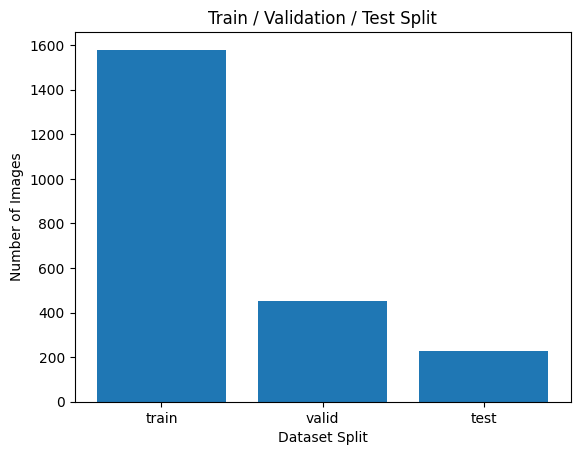

In [ ]:
import matplotlib.pyplot as plt

labels = list(counts.keys())
values = list(counts.values())

plt.figure()
plt.bar(labels, values)
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Train / Validation / Test Split")
plt.show()

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov8s.pt')

model.train(
    data='data.yaml',
    epochs=10,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab5ddca86e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
model = YOLO('yolov8s.pt')
model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,

    optimizer="AdamW",   # 🔥 Best for most cases
    lr0=0.001,           # initial learning rate
    momentum=0.9,        # works for SGD/Adam variants
    weight_decay=0.0005  # regularization
)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab5692543e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

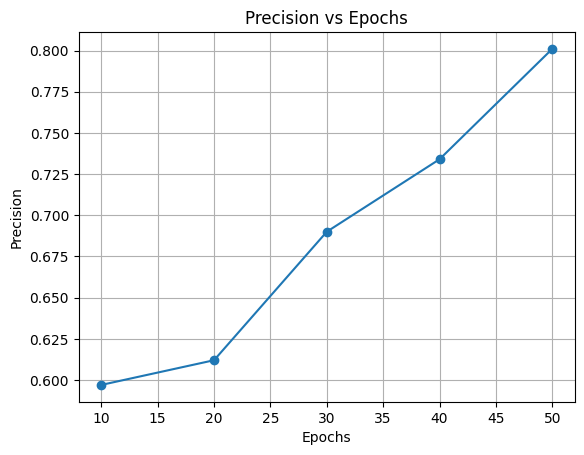

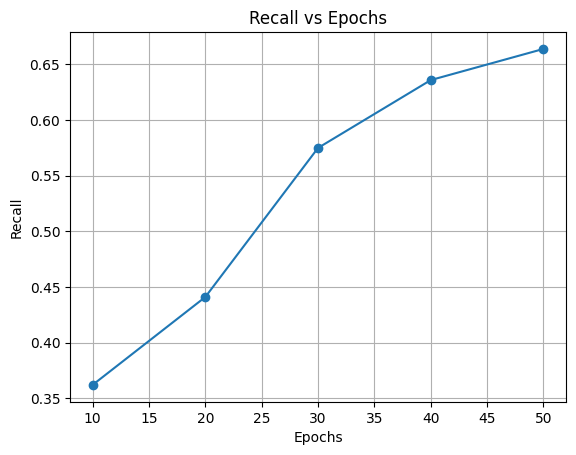

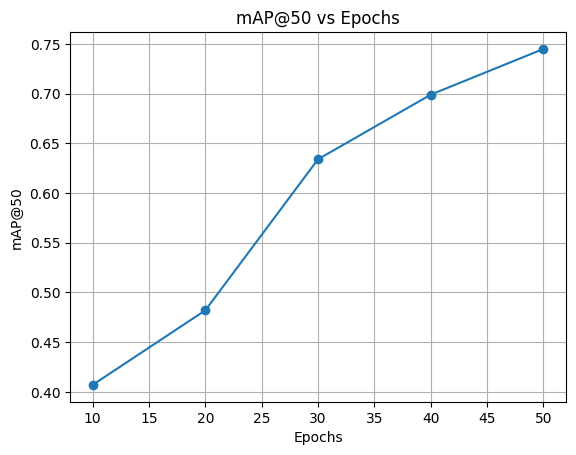

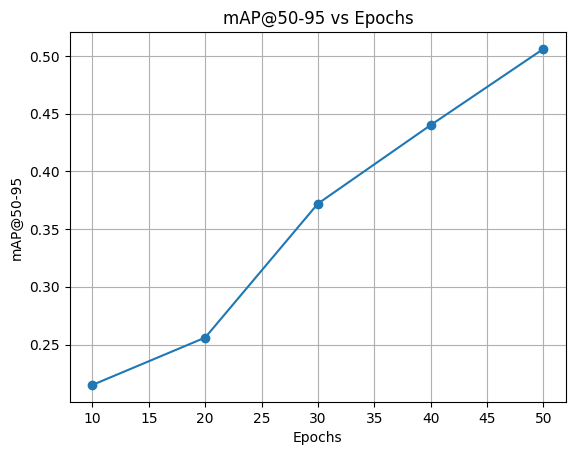

In [ ]:
import matplotlib.pyplot as plt

# 📊 Data from your table
epochs = [10, 20, 30, 40, 50]
precision = [0.597, 0.612, 0.690, 0.734, 0.801]
recall = [0.362, 0.441, 0.575, 0.636, 0.664]
map50 = [0.407, 0.482, 0.634, 0.699, 0.745]
map5095 = [0.215, 0.256, 0.372, 0.440, 0.506]

# 📈 Precision Graph
plt.figure()
plt.plot(epochs, precision, marker='o')
plt.title("Precision vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.grid()
plt.show()

# 📈 Recall Graph
plt.figure()
plt.plot(epochs, recall, marker='o')
plt.title("Recall vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.grid()
plt.show()

# 📈 mAP@50 Graph
plt.figure()
plt.plot(epochs, map50, marker='o')
plt.title("mAP@50 vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("mAP@50")
plt.grid()
plt.show()

# 📈 mAP@50-95 Graph
plt.figure()
plt.plot(epochs, map5095, marker='o')
plt.title("mAP@50-95 vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("mAP@50-95")
plt.grid()
plt.show()

In [ ]:
import os
print(os.getcwd())

/content/drive/MyDrive/Combined_Dataset


In [ ]:
import os

for root, dirs, files in os.walk("/", topdown=True):
    if "runs" in dirs:
        print(os.path.join(root, "runs"))
        break

/usr/local/lib/python3.12/dist-packages/openai/types/evals/runs


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "best.pt" in files:
        print("✅ Found best model at:", os.path.join(root, "best.pt"))

✅ Found best model at: /content/drive/MyDrive/Combined_Dataset/runs/detect/train/weights/best.pt
✅ Found best model at: /content/drive/MyDrive/Combined_Dataset/runs/detect/train2/weights/best.pt
✅ Found best model at: /content/drive/MyDrive/Final_dataset/runs/detect/weed_yolov8m_30epochs/weights/best.pt


In [ ]:
import shutil

source = "/content/drive/MyDrive/Combined_Dataset/runs/detect/train2/weights/best.pt"

destination = "/content/drive/MyDrive/Combined_Dataset/Combined_Dataset_Yolov8_best.pt"

shutil.copy(source, destination)

print("✅ Best model saved as Combined_Dataset_Yolov8_best.pt")

✅ Best model saved as Combined_Dataset_Yolov8_best.pt
